## Exploratory Data Analysis
### Movie Rating Prediction and Analysis
#### Goal
the goal of this project is to analyze movie-related features and build a machine learning model to predict audience ratings.

In [83]:
# Reading Data
import pandas as pd

movies = pd.read_csv('./data/Rotten Tomatoes Movies.csv')
movies.head()

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0
1,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0
2,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0
3,12 Angry Men (Twelve Angry Men),"A Puerto Rican youth is on trial for murder, a...",Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,2001-03-06,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0
4,"20,000 Leagues Under The Sea","This 1954 Disney version of Jules Verne's 20,0...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,2003-05-20,127.0,Disney,Fresh,89,27,74.0,68860.0


In [84]:
# Number of rows and columns 
movies.shape

(16638, 17)

In [85]:
# Choosing specific columns
movies = movies[['movie_title', 'rating', 'genre', 'in_theaters_date','runtime_in_minutes',
                 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count']]
movies.head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0
1,Please Give,R,Comedy,2010-04-30,90.0,86,140,64.0,11567.0
2,10,R,"Comedy, Romance",1979-10-05,118.0,68,22,53.0,14670.0
3,12 Angry Men (Twelve Angry Men),NR,"Classics, Drama",1957-04-13,95.0,100,51,97.0,105000.0
4,"20,000 Leagues Under The Sea",G,"Action & Adventure, Drama, Kids & Family",1954-01-01,127.0,89,27,74.0,68860.0


In [86]:
# Number of rows and columns 
movies.shape

(16638, 9)

In [87]:
# Checking data types
movies.dtypes

movie_title               str
rating                    str
genre                     str
in_theaters_date          str
runtime_in_minutes    float64
tomatometer_rating      int64
tomatometer_count       int64
audience_rating       float64
audience_count        float64
dtype: object

In [88]:
# Converting in_theaters_date to datatime field
movies['in_theaters_date'] = pd.to_datetime(movies.in_theaters_date)

In [89]:
# filtering on only movies from the 2010's and newer
movies = movies[movies.in_theaters_date.dt.year >= 2010]
movies.head(3)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0
1,Please Give,R,Comedy,2010-04-30,90.0,86,140,64.0,11567.0
97,Fireflies in the Garden,R,Drama,2011-10-14,98.0,22,54,45.0,45150.0


In [90]:
# checking the number of movies in the new data frame
movies.shape

(6053, 9)

In [91]:
# Sorting dataframe according to 'tomatometer_rating' and discovering 5 highest rated movies by critics
movies.sort_values('tomatometer_rating', ascending= False).head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
7318,High Ground,NR,"Documentary, Special Interest",2012-11-02,91.0,100,8,74.0,295.0
11941,Rodney King,NR,Drama,2017-04-28,52.0,100,9,NaN,NaN
1468,11:55,NR,Drama,2017-06-09,80.0,100,5,81.0,378.0
13051,Stations of the Elevated,NR,"Documentary, Musical & Performing Arts, Specia...",2014-10-17,45.0,100,8,33.0,124.0
2592,Among Wolves,NR,Documentary,2019-02-08,94.0,100,12,91.0,106.0


In [92]:
# Sorting dataframe according to 'audience_rating' and discovering 5 highest rated movies by audience
movies.sort_values('audience_rating', ascending= False).head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
14580,The Most Dangerous Year,NR,Documentary,2019-04-12,90.0,91,11,100.0,40.0
4239,Charm City,NR,Documentary,2018-10-19,108.0,100,16,100.0,24.0
14566,The Miners' Hymns,NR,"Documentary, Drama, Special Interest",2012-02-08,52.0,100,10,100.0,148.0
4027,Calling All Earthlings,NR,Documentary,2018-06-29,74.0,58,12,100.0,34.0
7137,Haunt,R,"Horror, Mystery & Suspense",2019-09-13,92.0,68,38,100.0,7.0


In [93]:
#These top movies seem to have very few critics and audience members writing the reviews. I want to look at only 
#the most popular movies. Therefore, I filter the movies data set to only include movies that have 100k+ audience ratings.
movies_popular = movies[movies.audience_count > 100000]
movies_popular.shape

(316, 9)

In [94]:
# highest rated popular movies by critics
movies_popular.sort_values('tomatometer_rating', ascending= False).head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
7558,How to Train Your Dragon,PG,"Animation, Kids & Family, Science Fiction & Fa...",2010-03-26,98.0,99,208,91.0,312342.0
7925,Inside Out,PG,"Animation, Kids & Family",2015-06-19,94.0,98,357,89.0,136125.0
15416,Toy Story 3,G,"Animation, Comedy, Kids & Family",2010-06-18,103.0,98,305,89.0,606931.0
16634,Zootopia,PG,"Action & Adventure, Animation, Comedy",2016-03-04,108.0,97,279,92.0,100946.0
9355,Mad Max: Fury Road,R,"Action & Adventure, Science Fiction & Fantasy",2015-05-15,120.0,97,410,85.0,127428.0


In [95]:
# highest rated popular movies by the audience
movies_popular.sort_values('audience_rating', ascending= False).head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
16634,Zootopia,PG,"Action & Adventure, Animation, Comedy",2016-03-04,108.0,97,279,92.0,100946.0
14397,The King's Speech,PG-13,Drama,2010-11-26,118.0,95,292,92.0,144306.0
4077,Captain America: The Winter Soldier,PG-13,"Action & Adventure, Science Fiction & Fantasy",2014-04-04,136.0,90,292,92.0,281524.0
6950,Guardians of the Galaxy,PG-13,"Action & Adventure, Science Fiction & Fantasy",2014-08-01,121.0,91,316,92.0,254717.0
14549,The Martian,PG-13,Science Fiction & Fantasy,2015-10-02,164.0,91,361,91.0,131093.0


In [96]:
# A lot of these popular movies seem to have a PG or PG-13 rating
# number of movies that fall under each type of rating
movies_popular.rating.value_counts()

rating
PG-13    160
R        100
PG        51
G          5
Name: count, dtype: int64

In [97]:
# The average audience rating for each movie rating type
movies_popular.groupby('rating')['audience_rating'].mean().sort_values(ascending =False)
# PG-13 movies are most highly rated

rating
PG-13    67.293750
PG       66.823529
G        66.200000
R        63.010000
Name: audience_rating, dtype: float64

In [98]:
# Creating a column in the DataFrame called 'Animation' and return a 1 if a movie is an 'Animation' movie and 0 otherwise. 
# and the same for Action & Adventure and Comedy

import numpy as np
# copy the movie to avoid a warning
movies_popular = movies[movies.audience_count > 100000].copy()

movies_popular['Animation'] = np.where(movies_popular.genre.str.contains('Animation'), 1, 0)
movies_popular['Action & Adventure'] = np.where(movies_popular.genre.str.contains('Action & Adventure'), 1, 0)
movies_popular['Comedy'] = np.where(movies_popular.genre.str.contains('Comedy'), 1, 0)

In [99]:
movies_popular.head(3)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0,0,1,1
248,Tron Legacy,PG,"Action & Adventure, Science Fiction & Fantasy",2010-12-17,125.0,51,239,63.0,171385.0,0,1,0
265,The Last Song,PG,"Drama, Kids & Family, Romance",2010-03-31,107.0,20,118,66.0,160777.0,0,0,0


In [100]:
# Creating a table where each row is a rating, each column is a genre and each value
# is the number of movies of that particular rating and genre.
movies_popular.groupby('rating')[['Animation', 'Action & Adventure', 'Comedy']].sum()

,Animation,Action & Adventure,Comedy
rating,,,
G,5,3,5
PG,26,27,29
PG-13,0,102,35
R,0,41,35


In [101]:
# Finding the average critic and audience rating for an Animation movie vs a non-Animation movie
movies_popular.groupby('Animation')[['tomatometer_rating', 'audience_rating']].mean()
# both critics and the general audience love animated movies

,tomatometer_rating,audience_rating
Animation,,
0,58.340351,64.831579
1,75.258065,75.161290


In [102]:
# Same for Action & Adventure
movies_popular.groupby('Action & Adventure')[['tomatometer_rating', 'audience_rating']].mean()
# the general audience likes action movies more than critics

,tomatometer_rating,audience_rating
Action & Adventure,,
0,59.111888,65.391608
1,60.734104,66.219653


In [103]:
# Same for Comedy column
movies_popular.groupby('Comedy')[['tomatometer_rating', 'audience_rating']].mean()
# comedies have lower ratings than other genres

,tomatometer_rating,audience_rating
Comedy,,
0,62.169811,67.353774
1,55.576923,62.769231


In [104]:
import seaborn as sns

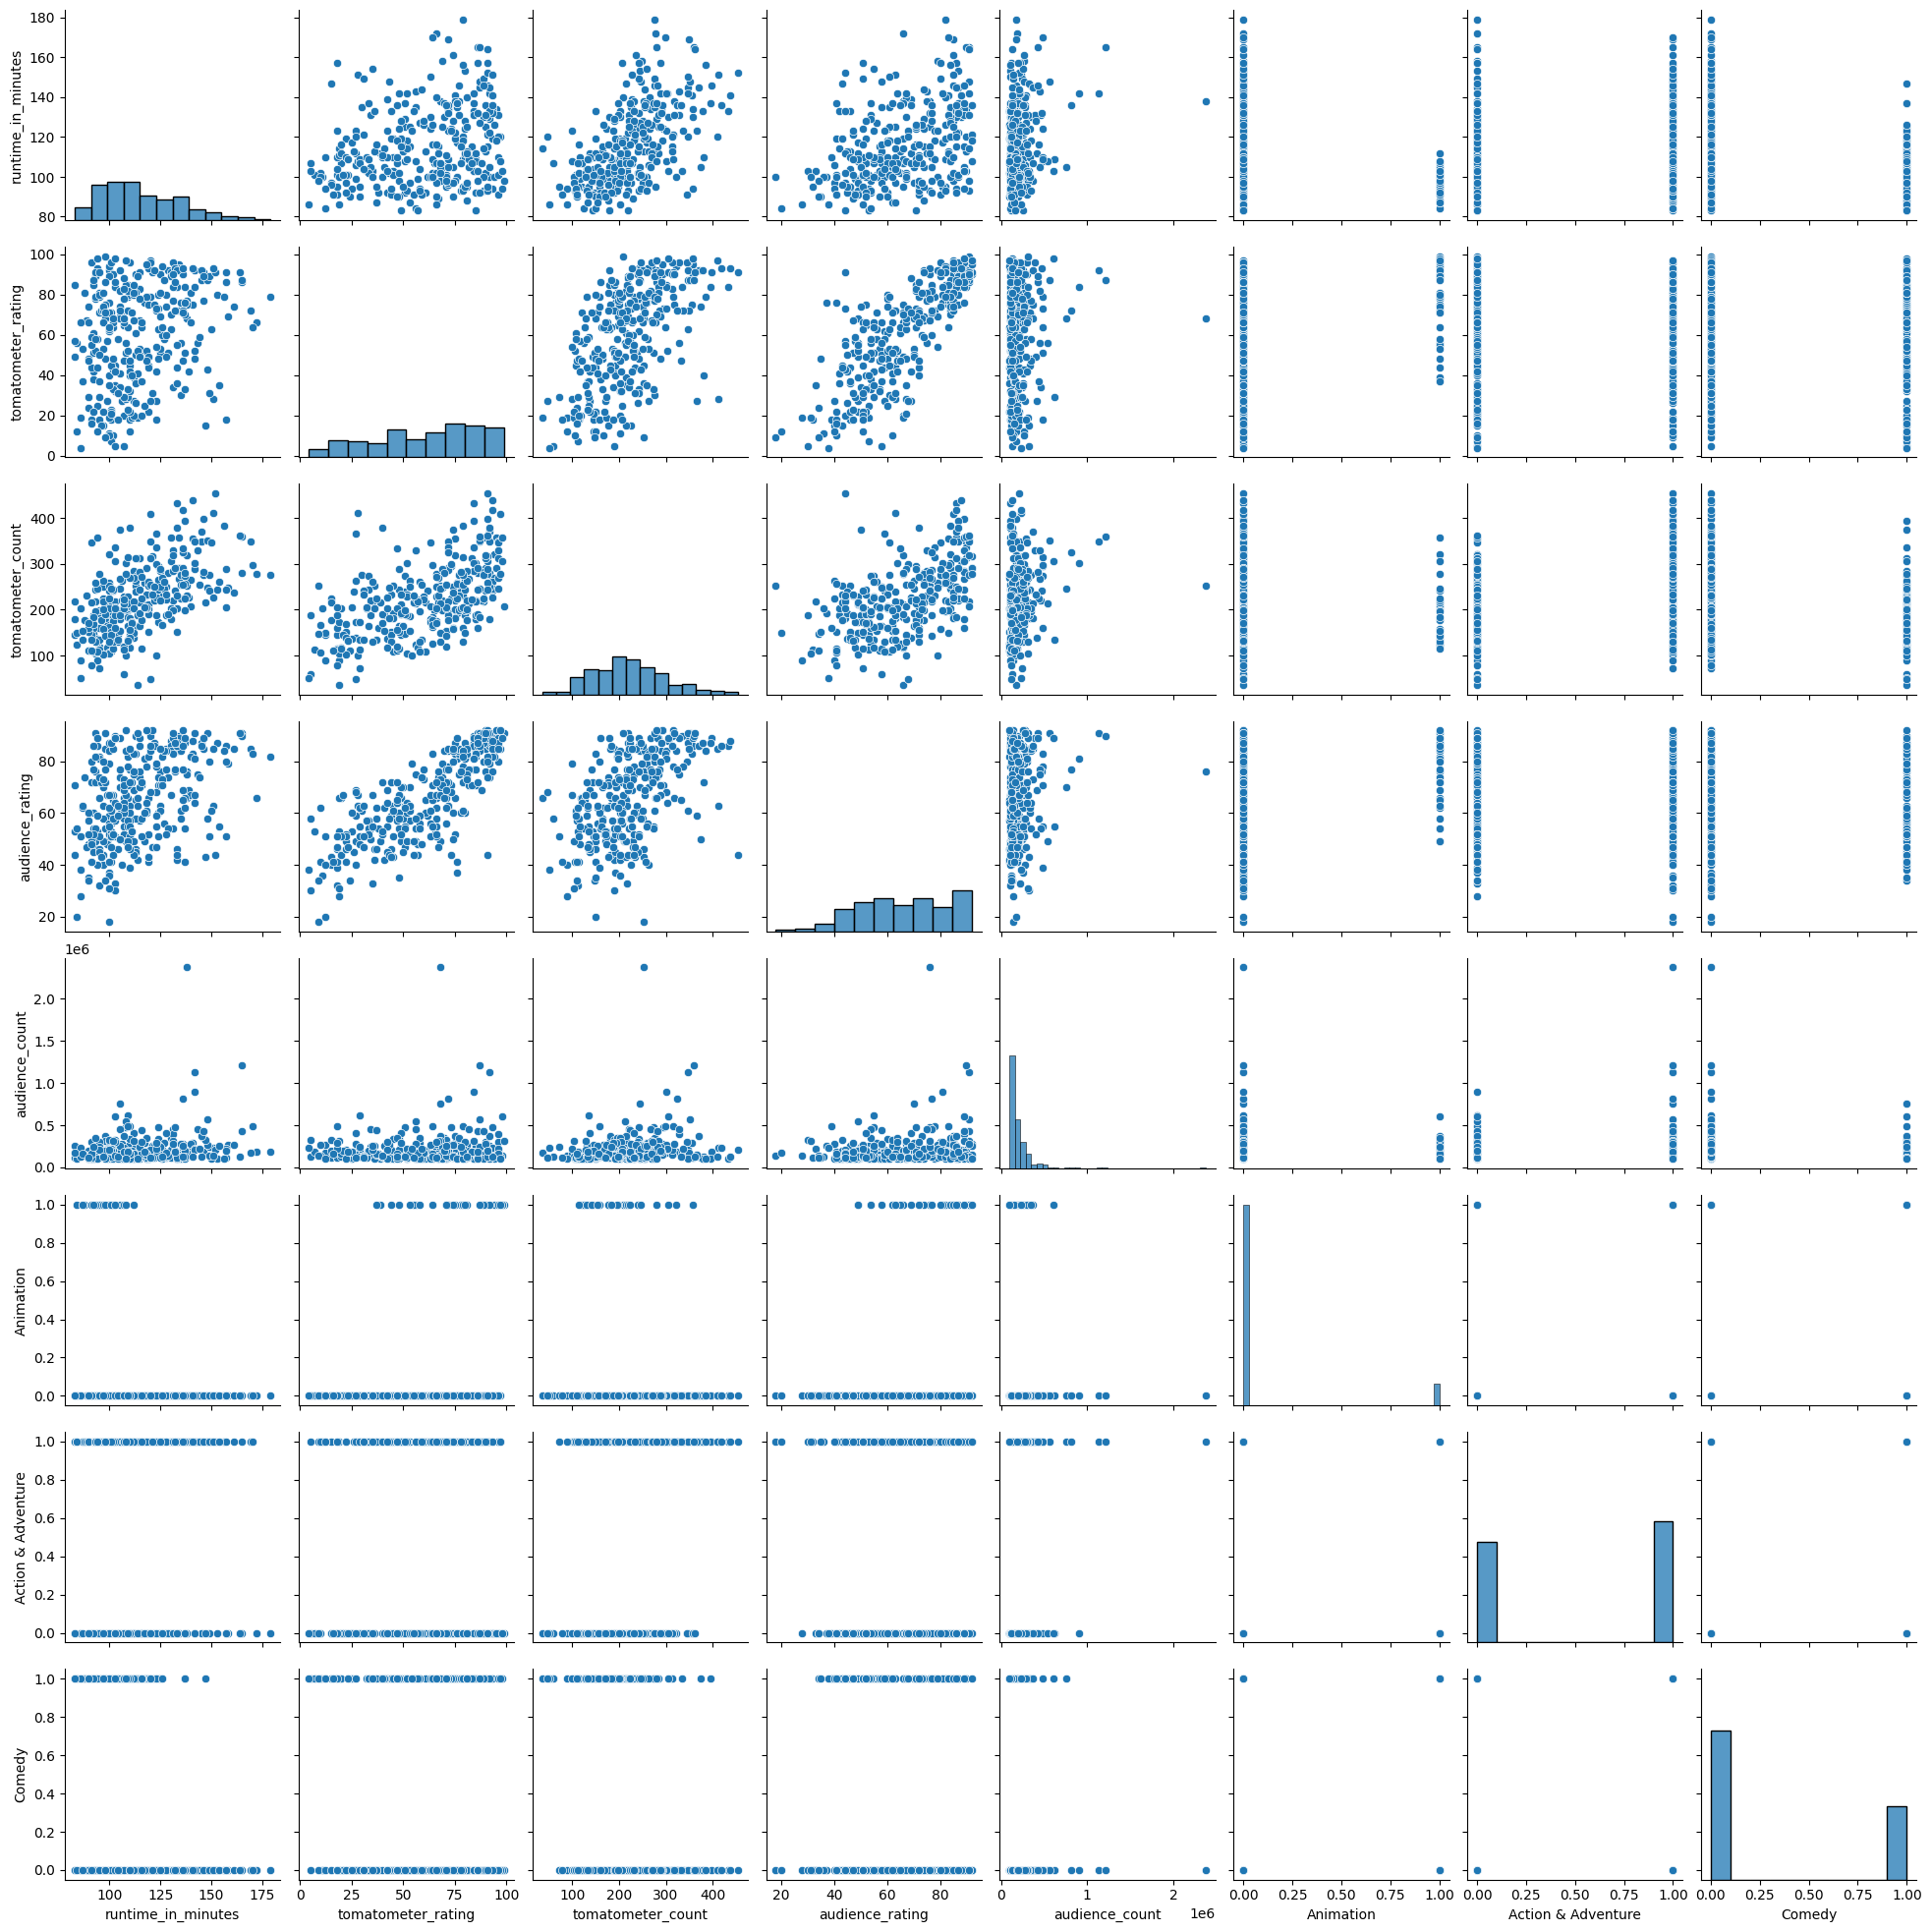

In [105]:
sns.pairplot(movies_popular);

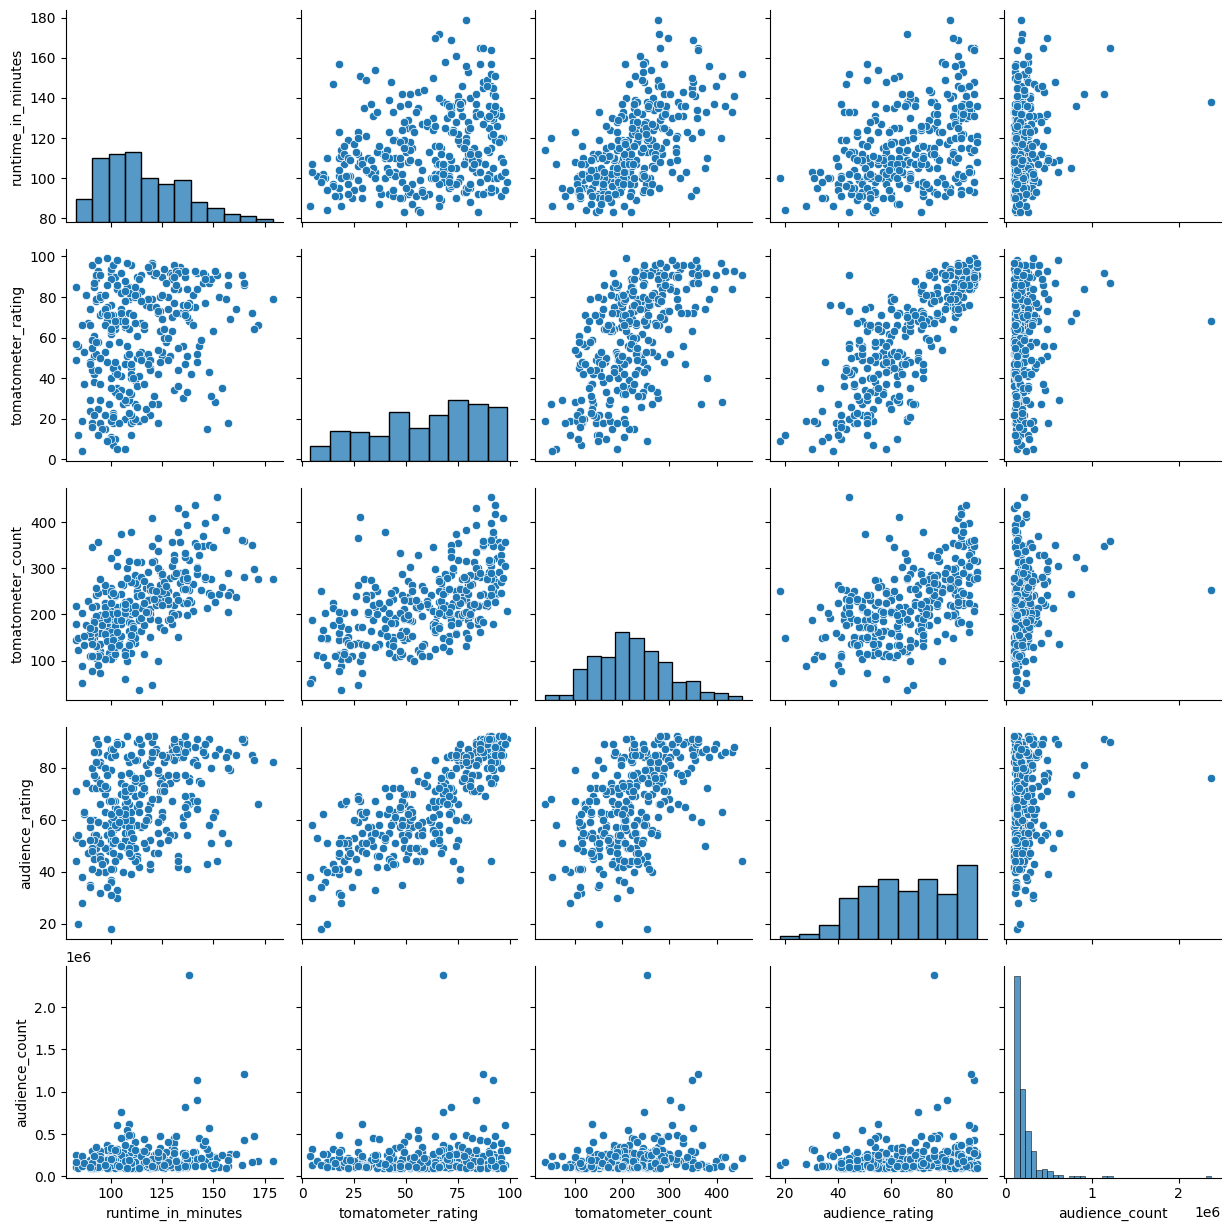

In [106]:
# excluding the newly created columns
sns.pairplot(movies_popular.iloc[:, :-3]);

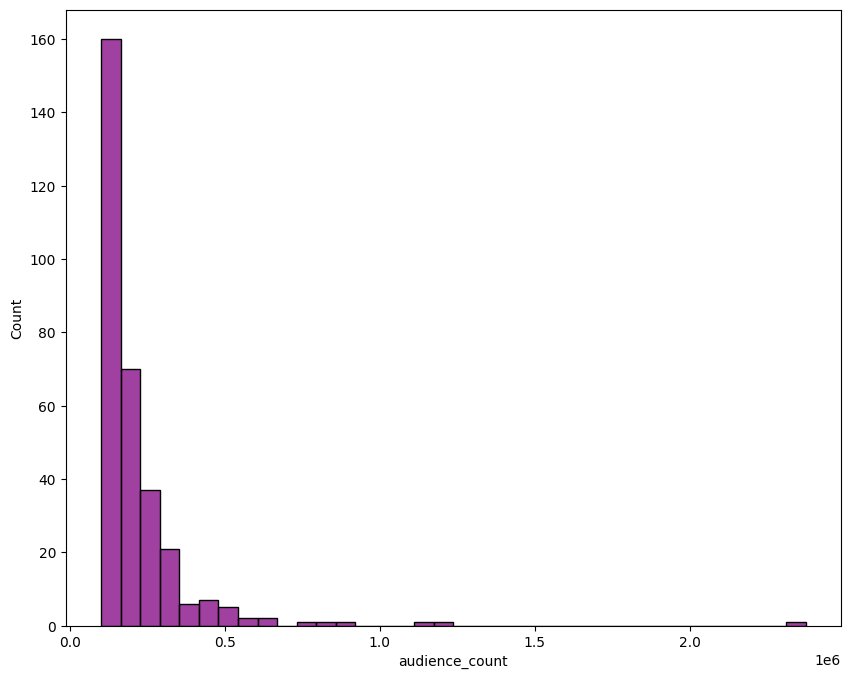

In [107]:
#It seems there is an outlier here
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.histplot(movies_popular['audience_count'], color = 'purple');

In [108]:
movies_popular[movies_popular.audience_count > 1000000]

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,Animation,Action & Adventure,Comedy
1646,Shutter Island,R,"Action & Adventure, Drama, Mystery & Suspense",2010-02-19,138.0,68,253,76.0,2373625.0,0,1,0
9581,Marvel's The Avengers,PG-13,"Action & Adventure, Science Fiction & Fantasy",2012-05-04,142.0,92,348,91.0,1134955.0,0,1,0
13936,The Dark Knight Rises,PG-13,"Action & Adventure, Drama, Mystery & Suspense",2012-07-20,165.0,87,360,90.0,1210957.0,0,1,0


In [109]:
# insights
# critics give harsher reviews -- there are quite a few low ratings in the tomatometer histogram
# the run time of movies seems to be correlated with the number of critic ratings
# the most popular movie is Shutter Island with lots of audience ratings and not as many critic ratings --
## this is so extreme that it could potentially be an outlier / error

In [110]:
target = "audience_rating"
features = ["runtime_in_minutes", "tomatometer_rating", "tomatometer_count","audience_count", "Animation", "Action & Adventure",
       "Comedy"]

In [111]:
X = movies_popular[features]
y = movies_popular[target]

In [112]:
X.isnull().sum()

runtime_in_minutes    0
tomatometer_rating    0
tomatometer_count     0
audience_count        0
Animation             0
Action & Adventure    0
Comedy                0
dtype: int64

In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [114]:
#Using Linear Regression to predict target value
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [115]:
#Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression")
print("MAE: ", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred)**0.5)
print("R2:", r2_score(y_test, lr_pred))

Linear Regression
MAE:  6.738235155395523
RMSE: 9.112805796454108
R2: 0.6557065401360962


In [116]:
#Random Forest model
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [117]:
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred)**0.5)
print("R2:", r2_score(y_test, rf_pred))

Random Forest
MAE: 6.849375
RMSE: 9.3149740002321
R2: 0.640260740056946


In [118]:
#Comparing Linear Regression and Random Forest
import pandas as pd
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, lr_pred)**0.5,
        mean_squared_error(y_test, rf_pred)**0.5
    ],
    "R2":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,6.738235,9.112806,0.655707
1,Random Forest,6.849375,9.314974,0.640261


## Model Comparison

Two models were evaluated: Linear Regression and Random Forest.

Linear Regression performed slightly better, with lower error (MAE, RMSE) and a higher R² score. This indicates that the relationship between the selected features and audience rating is relatively linear.

The Random Forest model did not significantly improve performance, suggesting that the current features do not benefit much from a more complex model.


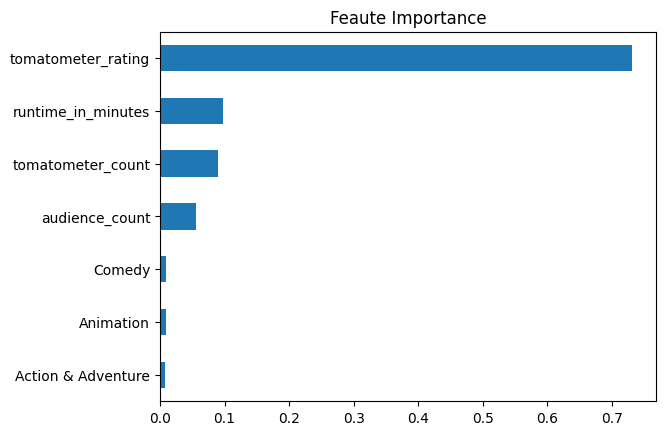

In [119]:
#Feature importance
importance = pd.Series(rf.feature_importances_, index= features)
importance = importance.sort_values()

importance.plot(kind="barh")
plt.title("Feaute Importance")
plt.show()

## Feature Importance

The feature importance plot shows how much each feature contributes to predicting audience rating in the Random Forest model.

Features with higher importance values have a greater impact on predictions. In this project, the most important features are:

- tomatometer_rating  
- audience_count  
- runtime_in_minutes  

This suggests that critic ratings and audience engagement play a key role in determining audience ratings.

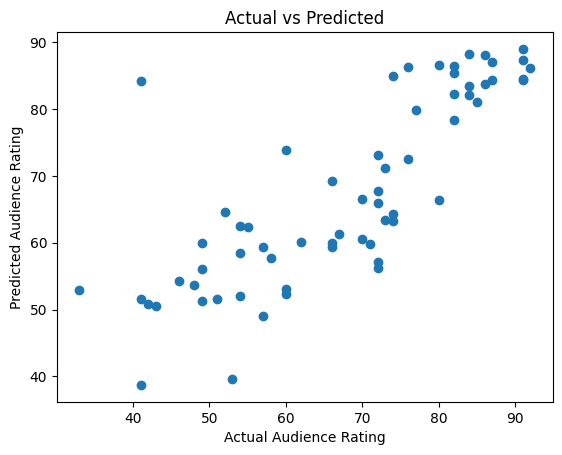

In [120]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Audience Rating")
plt.ylabel("Predicted Audience Rating")
plt.title("Actual vs Predicted")
plt.show()

## Actual vs Predicted Values

This plot compares the actual audience ratings with the predicted values from the model.

The points follow the general trend, which indicates that the model captures the relationship between features and audience rating.

However, there is some spread in the points, meaning the model makes errors for certain movies, especially at extreme values. This suggests that while the model performs reasonably well, there is still room for improvement.

## Conclusion

In this project, I analyzed movie-related data and built models to predict audience ratings.

Linear Regression performed slightly better than Random Forest, indicating that a simpler model is sufficient for this dataset.

The analysis shows that critic ratings and audience engagement are key factors influencing audience ratings.

Overall, this project demonstrates a complete machine learning workflow, including data preprocessing, exploratory analysis, model training, evaluation, and interpretation.